# Preprocesamiento y Preparación del Dataset
### Detección de Neumonía Bacteriana y Viral — Grupo 8


## 0. Configuración del entorno e instalación de librerías

In [ ]:

!pip install -q scikit-learn opencv-python-headless matplotlib seaborn tensorflow


In [ ]:
import os
import re
import shutil
import json
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.10.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Dataset ya descargado


In [ ]:
RAW_DIR = r'D:\Escritorio\Espol\IA\chest_xray'  #dirrecion de las fotos

assert os.path.isdir(RAW_DIR), (
    f"No se encontró '{RAW_DIR}'. Ajusta RAW_DIR a la ruta real donde tienes "
    f"la carpeta 'chest_xray' (con subcarpetas train/val/test) ya descargada."
)
print("Contenido de RAW_DIR:", os.listdir(RAW_DIR))


Contenido de RAW_DIR: ['chest_xray', 'test', 'train', 'val', '__MACOSX']


In [ ]:
# Carpeta local donde se guardarán
OUTPUT_DIR = './outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'gradcam_outputs'), exist_ok=True)
print('Los resultados se guardarán en:', os.path.abspath(OUTPUT_DIR))

Los resultados se guardarán en: d:\Escritorio\Espol\IA\v3, calor\V5.1\outputs


## 2. Preprocesamiento y estandarización (CU-01)


In [ ]:
def classify_filename(fname: str) -> str:
    """Determina la clase real (normal / bacteria / virus) a partir del nombre de archivo."""
    lower = fname.lower()
    if 'bacteria' in lower:
        return 'bacteria'
    elif 'virus' in lower:
        return 'virus'
    else:
        return 'normal'

records = []
for split in ['train', 'val', 'test']:
    for cls_dir in ['NORMAL', 'PNEUMONIA']:
        folder = os.path.join(RAW_DIR, split, cls_dir)
        if not os.path.isdir(folder):
            continue
        for fname in os.listdir(folder):
            if fname.lower().endswith(('.jpeg', '.jpg', '.png')):
                label = classify_filename(fname) if cls_dir == 'PNEUMONIA' else 'normal'
                records.append({'filepath': os.path.join(folder, fname), 'label': label})

df = pd.DataFrame(records)
print("Total de imágenes encontradas:", len(df))
print(df['label'].value_counts())


Total de imágenes encontradas: 5856
label
bacteria    2780
normal      1583
virus       1493
Name: count, dtype: int64


C:\Users\Cykes\AppData\Local\Temp\ipykernel_19168\414041487.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, order=['normal', 'bacteria', 'virus'],


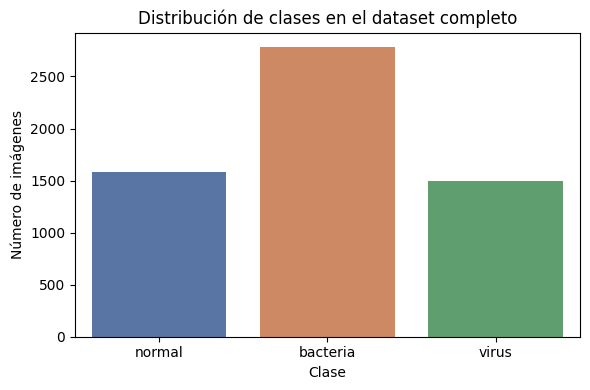

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, order=['normal', 'bacteria', 'virus'],
              palette=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Distribución de clases en el dataset completo')
plt.xlabel('Clase')
plt.ylabel('Número de imágenes')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distribucion_clases.png'), dpi=150)
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)

print("Train:", len(train_df), " Val:", len(val_df), " Test:", len(test_df))
for name, d in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"\n{name}:")
    print(d['label'].value_counts())


Train: 4684  Val: 586  Test: 586

Train:
label
bacteria    2224
normal      1266
virus       1194
Name: count, dtype: int64

Val:
label
bacteria    278
normal      159
virus       149
Name: count, dtype: int64

Test:
label
bacteria    278
normal      158
virus       150
Name: count, dtype: int64


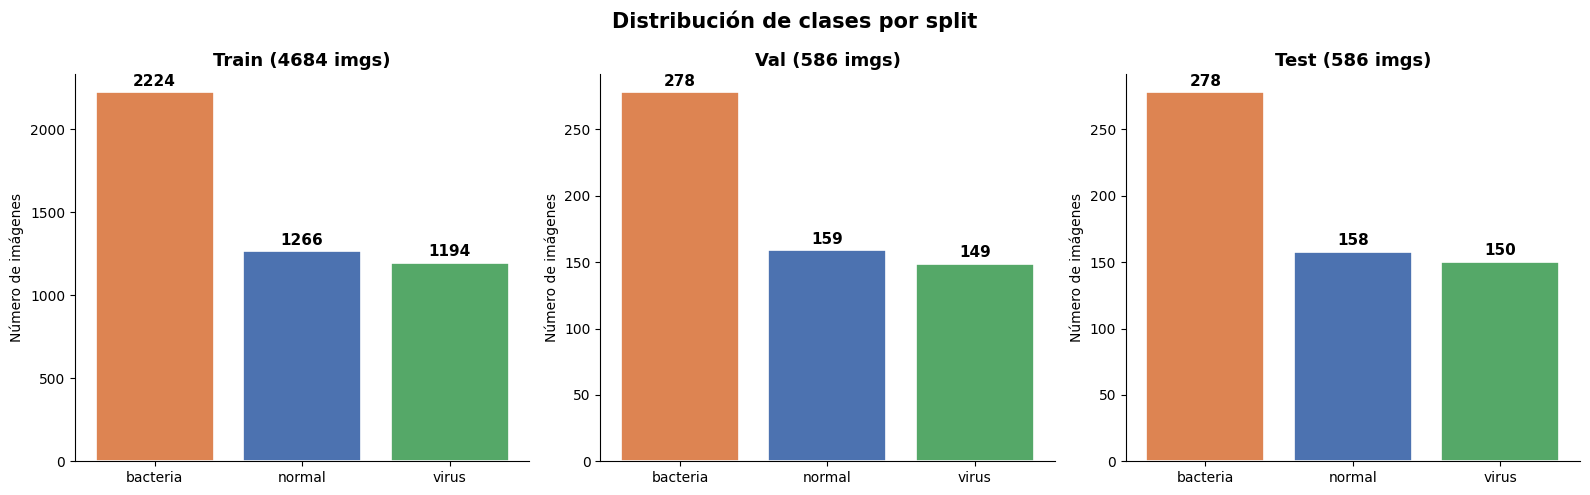

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#DD8452', '#4C72B0', '#55A868']  # bacteria, normal, virus

for ax, (name, split_df) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    counts = split_df['label'].value_counts().reindex(['bacteria', 'normal', 'virus']).fillna(0).astype(int)
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(counts.values) * 0.01,
                str(count), ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.set_title(f'{name} ({len(split_df)} imgs)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Número de imágenes')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Distribución de clases por split', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distribucion_clases_por_split.png'), dpi=150)
plt.show()


In [ ]:
CLASSES = ['normal', 'bacteria', 'virus']


## 3. Guardar los splits para los siguientes notebooks


In [ ]:
DATA_DIR = os.path.join(OUTPUT_DIR, 'data')
os.makedirs(DATA_DIR, exist_ok=True)

train_df.to_csv(os.path.join(DATA_DIR, 'train_df.csv'), index=False)
val_df.to_csv(os.path.join(DATA_DIR, 'val_df.csv'), index=False)
test_df.to_csv(os.path.join(DATA_DIR, 'test_df.csv'), index=False)

with open(os.path.join(DATA_DIR, 'classes.txt'), 'w') as f:
    f.write('\n'.join(CLASSES))

print("Guardado en:", DATA_DIR)
print(f"  train_df.csv  -> {len(train_df)} filas")
print(f"  val_df.csv    -> {len(val_df)} filas")
print(f"  test_df.csv   -> {len(test_df)} filas")
print(f"  classes.txt   -> {CLASSES}")


Guardado en: ./outputs\data
  train_df.csv  -> 4684 filas
  val_df.csv    -> 586 filas
  test_df.csv   -> 586 filas
  classes.txt   -> ['normal', 'bacteria', 'virus']
